In [1]:
### odtud už je to Vaše
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import torch

seed = 69
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)


df = pd.concat([pd.read_csv('train1.csv'), pd.read_csv('train2.csv')], axis=0)
df.reset_index(drop=True, inplace=True)

In [2]:
from sklearn.model_selection import train_test_split
X1, X_test, y1, y_test = train_test_split(df.drop(["label"], axis=1), df.label, shuffle=True, random_state=42, test_size=0.2)
X_train, X_val, y_train, y_val = train_test_split(X1, y1, shuffle=True, random_state=42, test_size=0.25)

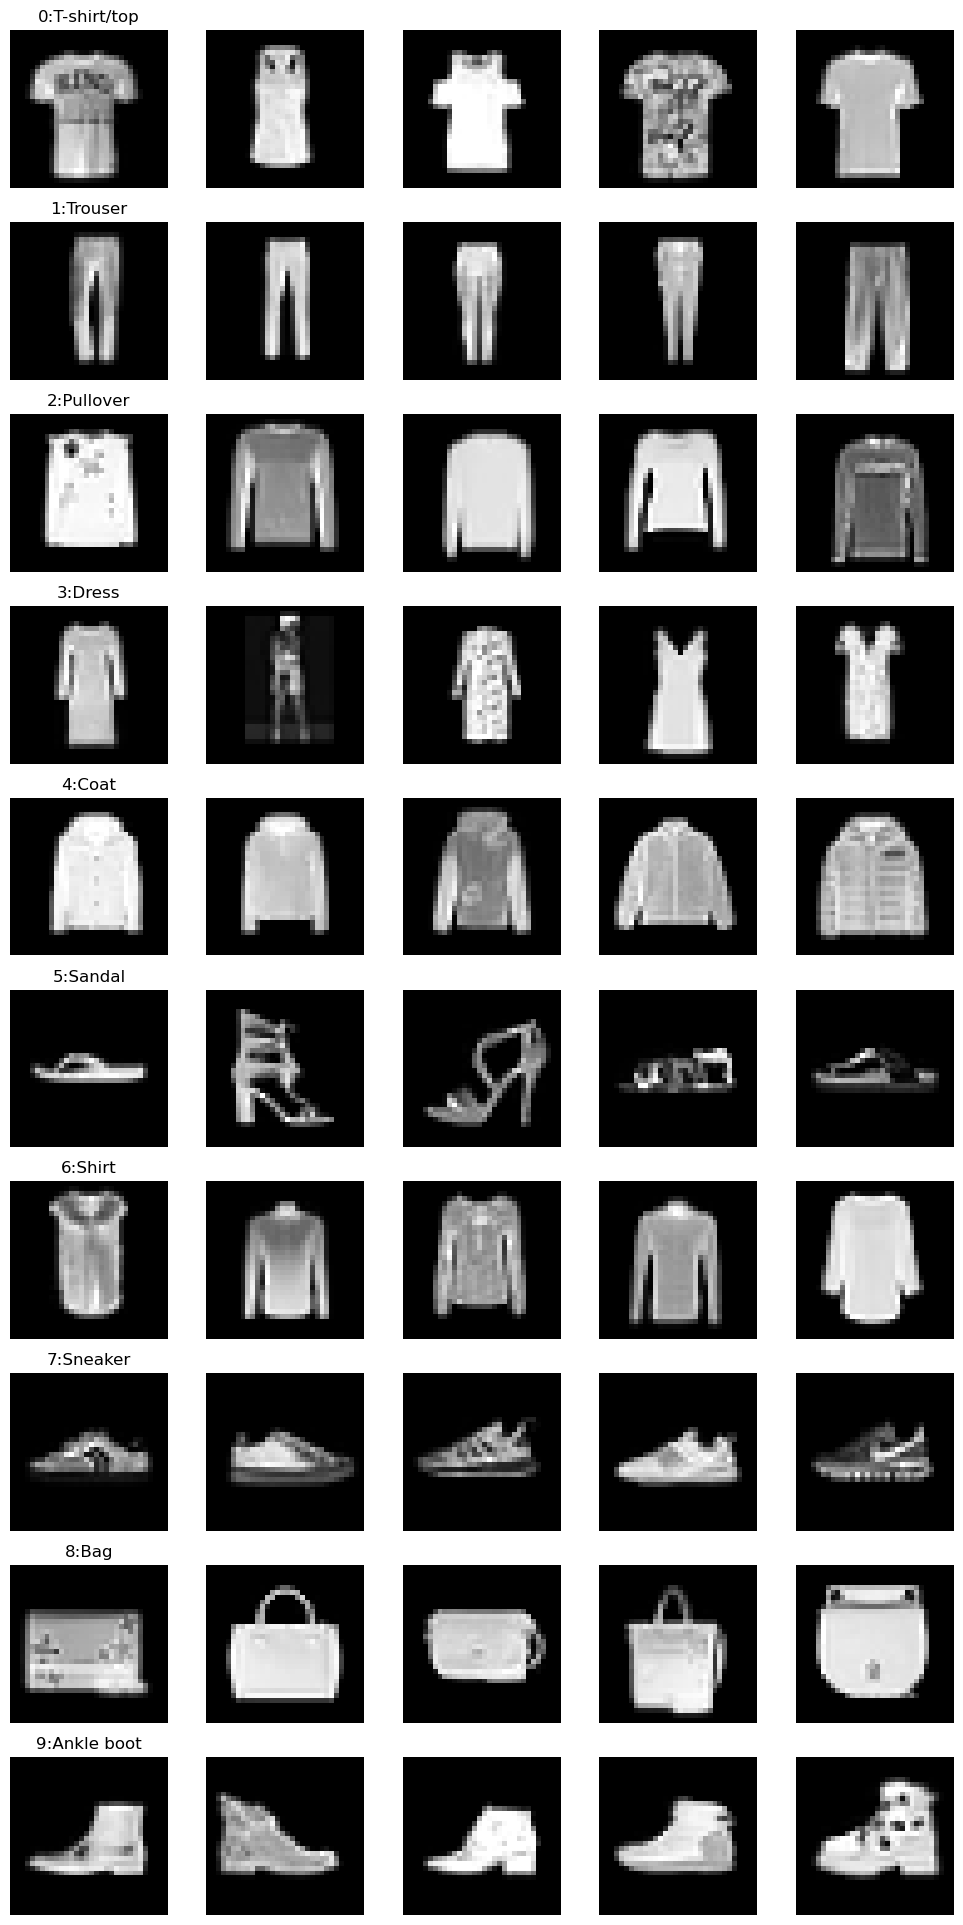

<Figure size 640x480 with 0 Axes>

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

class_names = ["T-shirt/top",
"Trouser",
"Pullover",
"Dress",
"Coat",
"Sandal",
"Shirt",
"Sneaker",
"Bag",
"Ankle boot"]

def show_examples_per_class(X, y, image_size=(32, 32), class_names=None, n_images=5):
    unique_classes = np.unique(y)
    n_classes = len(unique_classes)

    plt.figure(figsize=(n_images * 2, n_classes * 2))

    for row, cls in enumerate(unique_classes):
        indices = np.where(y == cls)[0]
        selected_indices = indices[:n_images]
        for col, idx in enumerate(selected_indices):
            plt_idx = row * n_images + col + 1

            if isinstance(X, pd.DataFrame):
                image = X.iloc[idx].values.reshape(image_size)
            else:
                image = X[idx].reshape(image_size)

            ax = plt.subplot(n_classes, n_images, plt_idx)
            ax.imshow(image, cmap='gray')
            ax.axis('off')

            # Nastavíme titulek pro první subplot v každém řádku
            if col == 0:
                title = class_names[cls] if class_names is not None else f"Třída {cls}"
                ax.set_title(f"{row}:{title}", fontsize=12)

    plt.tight_layout()
    plt.subplots_adjust(top=0.95) # Upravíme horní okraj pro titulky
    plt.savefig("obrazek_s_titulky.png")
    plt.show()
    plt.draw()

show_examples_per_class(X_train, y_train, image_size=(32, 32), class_names=class_names, n_images=5)

In [4]:
from torchvision import transforms
from PIL import Image
import numpy as np
import pandas as pd

X_train_original = X_train.copy(deep=True)
y_train_original = y_train.copy(deep=True)

augment = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10)
])
n_augmented = 30_000 
indices = np.random.choice(len(X_train), size=n_augmented, replace=True)

augmented_images = []
augmented_labels = []

for idx in indices:
    img_arr = X_train.iloc[idx].values.reshape(32, 32).astype(np.uint8)
    img = Image.fromarray(img_arr, mode='L')
    img_aug = augment(img)
    img_aug_np = np.array(img_aug).reshape(1, -1)  # zpět do 1D

    augmented_images.append(img_aug_np)
    augmented_labels.append(y_train.iloc[idx])

X_augmented = pd.DataFrame(np.vstack(augmented_images), columns=X_train.columns)
y_augmented = pd.Series(augmented_labels)

X_train = pd.concat([X_train, X_augmented], axis=0).reset_index(drop=True)
y_train = pd.concat([y_train, y_augmented], axis=0).reset_index(drop=True)


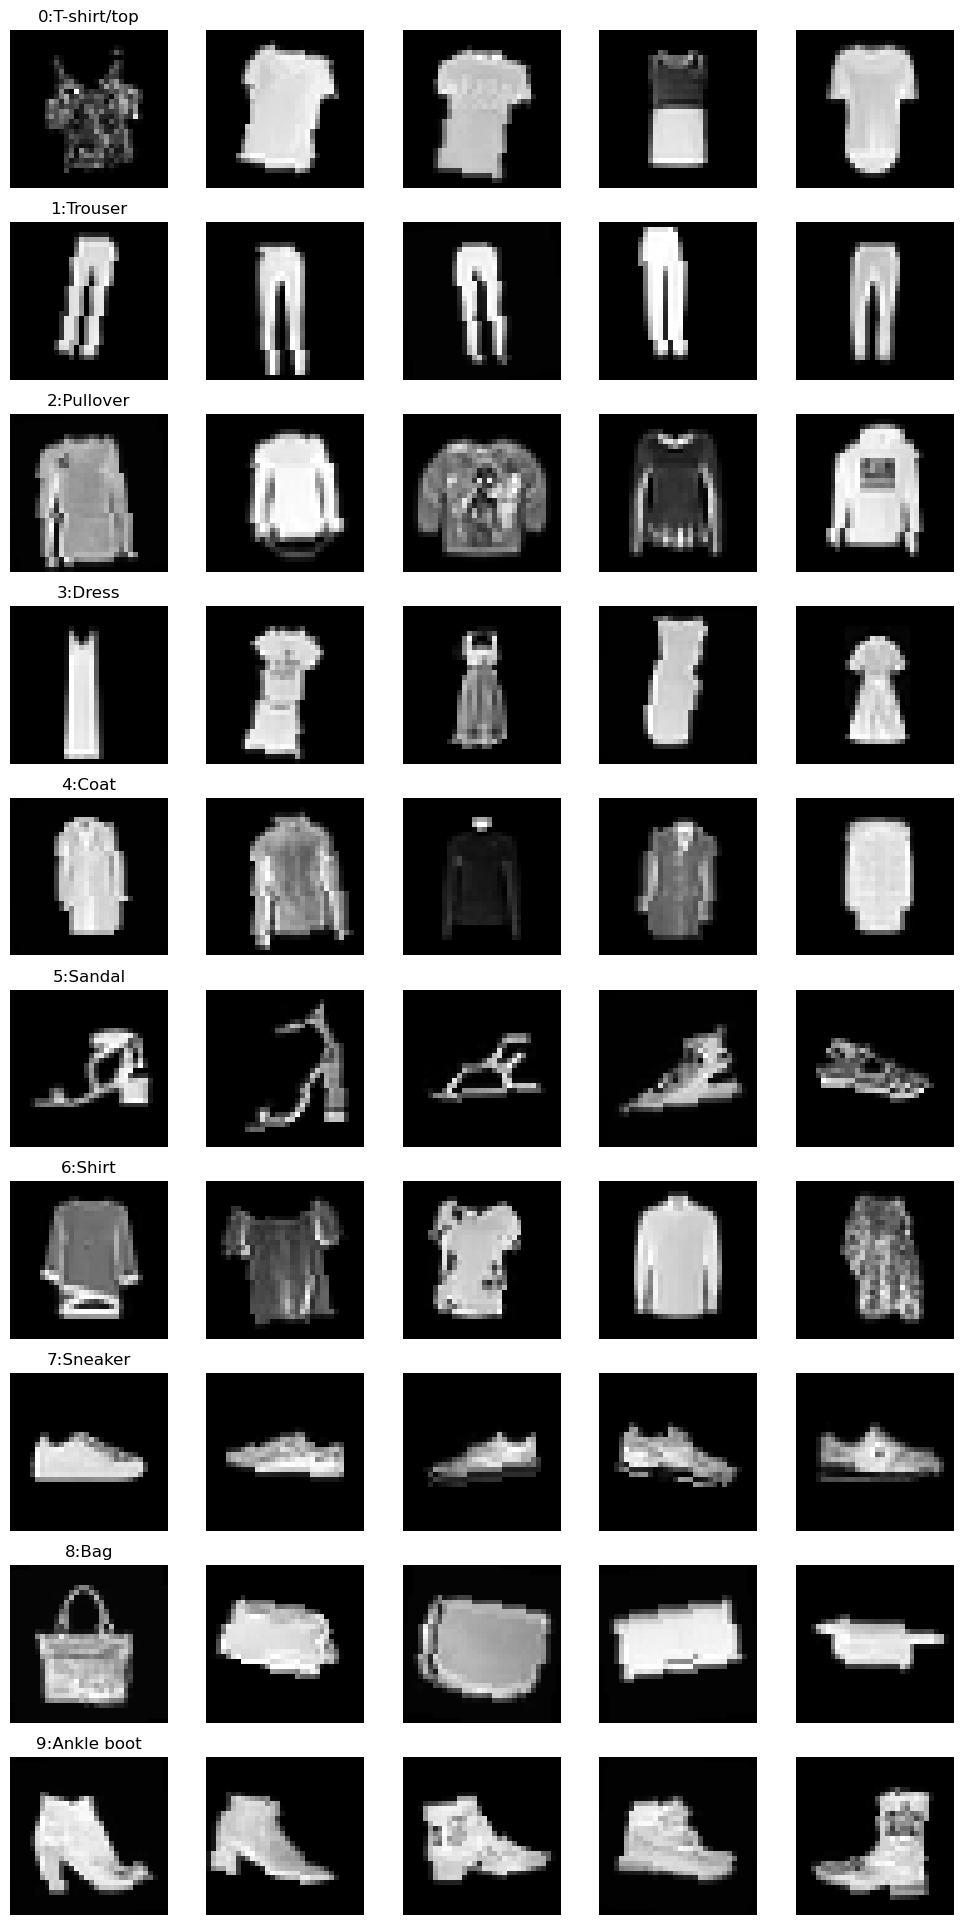

<Figure size 640x480 with 0 Axes>

In [5]:
show_examples_per_class(X_augmented, y_augmented, image_size=(32, 32), class_names=class_names, n_images=5)

In [6]:
indices

array([23755,  4041, 27243, ..., 11258,  9612,  4981])

In [11]:
class_to_augment = {
    6: 3500,
    4: 2500,
    2: 2500, 
    9: 600, 
    0: 100,   
    1: 100, 
    3: 100,   
    5: 100,  
    7: 300,   
    8: 100,
}


augment = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10)
])
X_train_double_augmented = X_train.copy(deep=True)
y_train_double_augmented = y_train.copy(deep=True)
for cls in class_to_augment:
    
    n_augmented = class_to_augment[cls]
    indices_curr_class = np.where(y_train_original == cls)[0]
    indices = np.random.choice(indices_curr_class, size=n_augmented, replace=True)
    print(indices)
    augmented_images = []
    augmented_labels = []
    
    for idx in indices:
        img_arr = X_train_original.iloc[idx].values.reshape(32, 32).astype(np.uint8)
        img = Image.fromarray(img_arr, mode='L')
        img_aug = augment(img)
        img_aug_np = np.array(img_aug).reshape(1, -1)  # zpět do 1D
    
        augmented_images.append(img_aug_np)
        augmented_labels.append(y_train.iloc[idx])
    X_augmented = pd.DataFrame(np.vstack(augmented_images), columns=X_train.columns)
    y_augmented = pd.Series(augmented_labels)
    X_train_double_augmented = pd.concat([X_train_double_augmented, X_augmented], axis=0).reset_index(drop=True)
    y_train_double_augmented = pd.concat([y_train_double_augmented, y_augmented], axis=0).reset_index(drop=True)

[ 7297  6028 12389 ... 22897 29778 17349]
[  751 15999 25755 ... 28192 18919 11536]
[19415 21521 28415 ...   766  3351  3146]
[ 4090  3857  9529 21227 24882  1516 27778 13797  3574 28576  9037  4930
  5858 10777  3491 21282 23929 23021 19977 16418 28831 20558 16198  2830
  7177  3019 29138 30661 26127 22959 17560 13340 28283 30942 20321  9846
 27767 15410  3615 22917  5042 10042  7291 19876 27090 25018 24056 22843
 13564 26107 13036 16354  6059  8617  1895   286 24982 28483 18653  6490
  1516  5395 25204  8270 17537   268   397 27767 10771 18512  9397 28676
 28871 22911 12883  2060 17421  7728  6088 13487 30093 24882 29965 11459
 15224  9936   600  4763 13106  6848 31480 25629 13949 22442  1556  1556
  9549 30014  8569  7009 29965 18966  5487 24356  8968 13374 11747 28177
  2262 19581 12610 14822  1401  4588 12279   917 15313 29008 25441 11108
  7181  7394  2576 23879   882  2925  4356  7387  2528 31054  6923  2921
 28537 20459 13032 17395 23241 24618 18270 26449  9480 11598 16967 1875

In [10]:
y_train_double_augmented[71000:]

71000    7
71001    7
71002    7
71003    7
71004    7
        ..
71395    8
71396    8
71397    8
71398    8
71399    8
Length: 400, dtype: int64

NameError: name 'lol' is not defined